## WESM Price Prediction - Model 2: Neural Network

# Using a Neural Network

First we need to ensure consistency across all data types to be able to use Tensor later on. So, we will convert the `month_year` feature into a datetime variable and separate them into two categories: `month` and `year`.

In [ ]:
# Convert string to datetime
df['date_col'] = pd.to_datetime(df['month_year'], format='%Y-%m')

df['year'] = df['date_col'].dt.year
df['month'] = df['date_col'].dt.month

`X_gwap` will contain all the features aside from `GWAP` and `gwap_range` as those will serve as our label. Time-based columns are also dropped since we have already made separate columns for `year` and `month`. `y_gwap` will contain the GWAP and serve as our label.

In [ ]:
# remove datetime since we already have separate columns
X_gwap = df.drop(["GWAP", "gwap_range", "datetime", "month_year", "date_col"], axis=1)

# Transforms the class variable into a matrix of shape (n_samples, 1)
y_gwap = df["GWAP"].values

X_gwap.head()

,energy_demand_mw,energy_supply_mw,energy_shortage_mw,reserve_demand_mw,reserve_supply_mw,outage_count,GWAP_Lag_1,GWAP_Lag_12,GWAP_Lag_288,year,month
0,8549.80,8592.66,-42.86,1368.0,1368.0,3.0,3127.6873,2528.3538,2321.6376,2025,11
1,8502.47,8621.92,-119.45,1368.0,1368.0,3.0,2590.3569,2534.1721,2394.5301,2025,11
2,8503.43,8621.24,-117.81,1368.0,1368.0,3.0,2379.0282,2484.7641,2325.4293,2025,11
3,8446.04,8586.57,-140.53,1368.0,1368.0,3.0,2378.7328,2720.1748,2320.9318,2025,11
4,8474.76,8589.58,-114.82,1368.0,1368.0,3.0,2378.4848,2756.0153,2314.6513,2025,11


In [ ]:
y_gwap

array([2590.3569, 2379.0282, 2378.7328, ..., 2831.0809, 2830.2625,
       2730.0929], shape=(15260,))

## Splitting the Data

Dividing the dataset into training set, validation set, and test set. The test and validation set will contain 15% of the original dataset, while the training set will contain 70%.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate the test set from the train and validation sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_gwap,
    y_gwap,
    test_size=0.15,
    random_state=1,
    shuffle=True
)

# Separate the validation set from the train set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.17647,  # 15% of leftover data
    random_state=1,
    shuffle=True
)

In [ ]:
print("Size of training set: ", X_train.shape)
print("Size of validation set: ", X_val.shape)
print("Size of test set: ", X_test.shape)

Size of training set:  (10682, 11)
Size of validation set:  (2289, 11)
Size of test set:  (2289, 11)


## Standardizing the Data

Since we are working with high-magnitude values, we will standardize our data to lessen the probability of overshooting.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)

# fit on training data only to prevent data leakage (happens when using test data to compute mena/std)
X_test = scaler_X.transform(X_test)
X_val = scaler_X.transform(X_val)  

In [ ]:
scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))

# fit on training data only to prevent data leakage (happens when using test data to compute mena/std)
y_test = scaler_y.transform(y_test.reshape(-1, 1))
y_val = scaler_y.transform(y_val.reshape(-1, 1))

## Converting to Tensor

Convert the np.ndarrays to datatype torch.Tensor

In [ ]:
X_train = torch.Tensor(X_train)
y_train = torch.Tensor(y_train)
X_test = torch.Tensor(X_test)
y_test = torch.Tensor(y_test)
X_val = torch.Tensor(X_val)
y_val = torch.Tensor(y_val)

## Setting up the Neural Network

*Hyperparameter tuning to be done later, this is just to see how it works with a random model

*nn will be coded manually, this is just for testing

In [ ]:
input_size = X_train.shape[1]  # 11 features
hidden_layers = [64, 32]      # to be tuned
activation = nn.ReLU       
output_size = 1

layers = []
in_dim = input_size

for h in hidden_layers:
    layers.append(nn.Linear(in_dim, h))
    layers.append(activation())
    in_dim = h
layers.append(nn.Linear(in_dim, output_size))

model = nn.Sequential(*layers)

## Loss and Optimizer

In [ ]:
# used for regression
criterion = nn.MSELoss()  
learning_rate = 0.001      # to be tuned
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Training

In [ ]:
epochs = 200   # to be tuned
batch_size = 32  # to be tuned
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    
    # Forward propagation
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    
    # Backward propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Validation
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Train Loss={loss.item():.4f}, Val Loss={val_loss.item():.4f}")

Epoch 0: Train Loss=0.1484, Val Loss=0.2478
Epoch 20: Train Loss=0.1474, Val Loss=0.2473
Epoch 40: Train Loss=0.1465, Val Loss=0.2466
Epoch 60: Train Loss=0.1455, Val Loss=0.2455
Epoch 80: Train Loss=0.1445, Val Loss=0.2446
Epoch 100: Train Loss=0.1436, Val Loss=0.2437
Epoch 120: Train Loss=0.1426, Val Loss=0.2426
Epoch 140: Train Loss=0.1416, Val Loss=0.2418
Epoch 160: Train Loss=0.1407, Val Loss=0.2414
Epoch 180: Train Loss=0.1399, Val Loss=0.2411


## Hyperparameter Tuning

...

## Evaluation

In [ ]:
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)

# inverse-transform the predictions to get them back to the original scale
y_pred_original = scaler_y.inverse_transform(y_pred_test.numpy())
y_test_original = scaler_y.inverse_transform(y_test.numpy())

Visualization

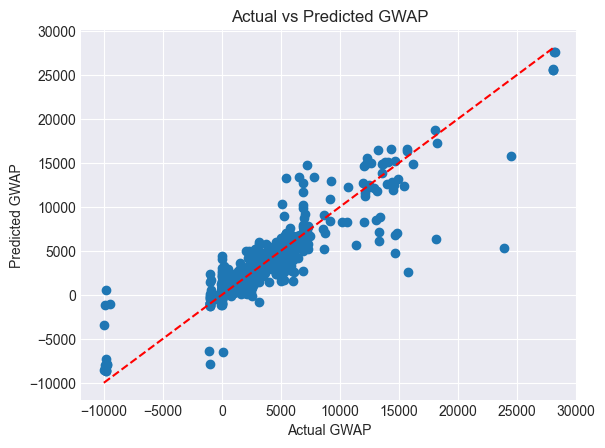

In [ ]:
plt.scatter(y_test_original, y_pred_original)
plt.xlabel("Actual GWAP")
plt.ylabel("Predicted GWAP")
plt.title("Actual vs Predicted GWAP")
plt.plot([min(y_test_original), max(y_test_original)],
         [min(y_test_original), max(y_test_original)],
         'r--')  # perfect prediction line
plt.show()

Text(0.5, 1.0, 'Loss for each training epoch')

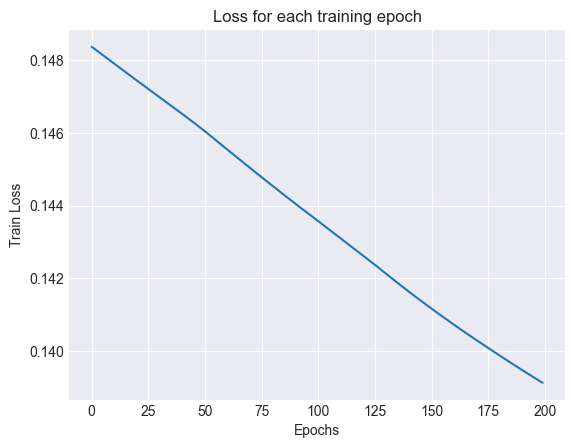

In [ ]:
x_values = [i for i in range(len(train_losses))]
y_values = train_losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.title('Loss for each training epoch')

Text(0.5, 1.0, 'Loss for each training epoch')

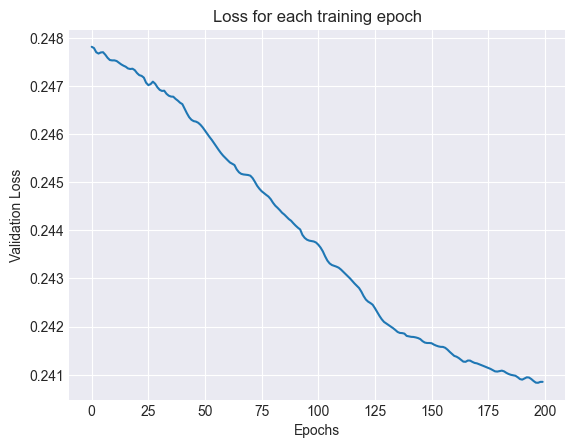

In [ ]:
x_values = [i for i in range(len(val_losses))]
y_values = val_losses

plt.plot(x_values, y_values)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Loss for each validation epoch')

First we need to ensure consistency across all data types to be able to use Tensor later on. So, we will convert the `month_year` feature into a datetime variable and separate them into two categories: `month` and `year`.

In [ ]:
# Convert string to datetime
df['date_col'] = pd.to_datetime(df['month_year'], format='%Y-%m')

df['year'] = df['date_col'].dt.year
df['month'] = df['date_col'].dt.month

`X_gwap` will contain all the features aside from `GWAP` and `gwap_range` as those will serve as our label. Time-based columns are also dropped since we have already made separate columns for `year` and `month`. `y_gwap` will contain the GWAP and serve as our label.